# **Project: Hate Speech Detection using Transformers (Deep Learning)**

**Problem Statement:**

The term hate speech is understood as any type of verbal, written or behavioural communication that attacks or uses derogatory or discriminatory language against a person or group based on what they are, in other words, based on their religion, ethnicity, nationality, race, colour, ancestry, sex or another identity factor. In this problem, We will take you through a hate speech detection model with Machine Learning and Python.

Hate Speech Detection is generally a task of sentiment classification. So for training, a model that can classify hate speech from a certain piece of text can be achieved by training it on a data that is generally used to classify sentiments. So for the task of hate speech detection model, We will use the Twitter tweets to identify tweets containing  Hate speech.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Importing Dataset

In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv('/content/drive/MyDrive/Final Project/train_E6oV3lV.csv')
df.head(10)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
5,6,0,[2/2] huge fan fare and big talking before the...
6,7,0,@user camping tomorrow @user @user @user @use...
7,8,0,the next school year is the year for exams.ð...
8,9,0,we won!!! love the land!!! #allin #cavs #champ...
9,10,0,@user @user welcome here ! i'm it's so #gr...


## 2. Data understanding

### 2.1 Number of Observations and Features

In [ ]:
print(f'Number of Observations: {df.shape[0]}')
print(f'Number of Features: {df.shape[1]}')

Number of Observations: 31962
Number of Features: 3


### 2.2 Features in the Dataset

In [ ]:
df.columns

Index(['id', 'label', 'tweet'], dtype='object')

### 2.3 Data Types for Each Column

In [ ]:
df.dtypes

,0
id,int64
label,int64
tweet,object


### 2.4 Data Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


### 2.5 Dataset Size

In [ ]:
df.size

95886

### 2.6 Predictor and Target Variable

In [ ]:
# Predictor
predictor = df[['tweet']]
predictor.tail()




,tweet
31957,ate @user isz that youuu?ðððððð...
31958,to see nina turner on the airwaves trying to...
31959,listening to sad songs on a monday morning otw...
31960,"@user #sikh #temple vandalised in in #calgary,..."
31961,thank you @user for you follow


In [ ]:
# Target
target = df[['label']]
target.tail()

,label
31957,0
31958,0
31959,0
31960,1
31961,0


### 2.7 Missing Values Check



In [ ]:
df.isnull().sum()

,0
id,0
label,0
tweet,0


### 2.8 Checking Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

### 2.9 Class Distribution and Pie Chart

Hate Speech = 2242
Free Speech = 29720


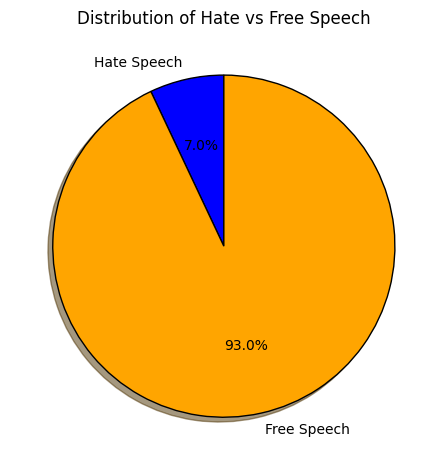

In [ ]:
hate_speech = df[df['label'] == 1].shape[0]
free_speech = df[df['label'] == 0].shape[0]

print('Hate Speech =', hate_speech)
print('Free Speech =', free_speech)

# Visualization
import matplotlib.pyplot as plt

speech = [hate_speech, free_speech]
label_names = ["Hate Speech", "Free Speech"]

plt.pie(speech, labels=label_names, shadow=True, wedgeprops={'edgecolor': 'black'},
        autopct='%1.1f%%', startangle=90, colors=['blue', 'orange'])

plt.title('Distribution of Hate vs Free Speech')
plt.tight_layout()
plt.show()


### 2.10 Outlier Detection (Text Length-Based)

count    31962.000000
mean        84.739628
std         29.455749
min         11.000000
25%         63.000000
50%         88.000000
75%        108.000000
max        274.000000
Name: text_length, dtype: float64


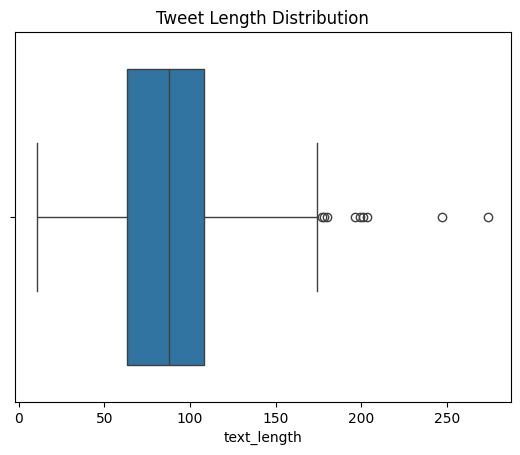

Upper Outlier Threshold: 138.0
Lower Outlier Threshold: 21.0


In [ ]:
df['text_length'] = df['tweet'].apply(len)

# Descriptive stats
print(df['text_length'].describe())

# Outliers: Very long or very short tweets
import seaborn as sns
sns.boxplot(x=df['text_length'])
plt.title("Tweet Length Distribution")
plt.show()

# Thresholds for outliers
upper_threshold = df['text_length'].quantile(0.99)
lower_threshold = df['text_length'].quantile(0.01)

print(f"Upper Outlier Threshold: {upper_threshold}")
print(f"Lower Outlier Threshold: {lower_threshold}")


### 2.11 Skewness in Tweet Length

In [ ]:
print(f"Skewness in tweet length: {df['text_length'].skew()}")


Skewness in tweet length: -0.22923564654998468


## 3. Data Preprocessing

In the data preprocessing phase, we cleaned the tweets to ensure the text is consistent and noise-free before feature extraction. We applied the following operations:

1.  Convert all characters to lowercase for uniformity.
2.  Remove User Mentions: Twitter handles (e.g., @user) were removed as they don't add semantic value.
3. Remove URLs: URLs were removed to avoid noise.
4. Remove Special Characters & Digits: Only alphabetic characters were retained.
5. Strip Whitespace: Removed leading and trailing spaces.






### 3.1 Text Cleaning

#### 3.1.1 Lowercasing

In [ ]:
import re

In [ ]:
def to_lowercase(text):
    return text.lower()

df['tweet'] = df['tweet'].apply(to_lowercase)
df.head()


,id,label,tweet,text_length
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


#### 3.1.2 Remove User Mentions (@tags)

In [ ]:
def remove_mentions(text):
    return re.sub(r'@[\w]*', '', text)

df['tweet'] = df['tweet'].apply(remove_mentions)
df.head()


,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so sel...,102
1,2,0,thanks for #lyft credit i can't use cause th...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


####  3.1.3 Remove URLs

In [ ]:
def remove_urls(text):
    return re.sub(r'http\S+', '', text)

df['tweet'] = df['tweet'].apply(remove_urls)
df.head()

,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so sel...,102
1,2,0,thanks for #lyft credit i can't use cause th...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


#### 3.1.4 Remove Special Characters and Digits

In [ ]:
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters and whitespace

df['tweet'] = df['tweet'].apply(remove_special_chars)
df.head()

,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so sel...,102
1,2,0,thanks for lyft credit i cant use cause they...,122
2,3,0,bihday your majesty,21
3,4,0,model i love u take with u all the time in u...,86
4,5,0,factsguide society now motivation,39


#### 3.1.5 Strip Leading and Trailing Whitespace

In [ ]:
def strip_whitespace(text):
    return text.strip()

df['tweet'] = df['tweet'].apply(strip_whitespace)
df.head()


,id,label,tweet,text_length
0,1,0,when a father is dysfunctional and is so selfi...,102
1,2,0,thanks for lyft credit i cant use cause they d...,122
2,3,0,bihday your majesty,21
3,4,0,model i love u take with u all the time in ur,86
4,5,0,factsguide society now motivation,39
